# 📈 Store Sales Forecasting using Time Series Analysis

### Kaggle Competition: Store Sales - Time Series Forecasting

This notebook explores a machine learning approach to forecast retail sales across multiple stores and product families using historical sales data.

The workflow includes:

- Data loading and exploration
- Feature engineering (time-based and lag features)
- Time series modelling using LightGBM
- Model evaluation using RMSLE
- Generating final predictions for submission

The objective is to predict daily sales for each store and product family combination.

---

# 📊 Dataset Overview

The dataset contains historical sales data for multiple stores and product families.

Main datasets used:

| Dataset | Description |
|------|------|
| **train.csv** | Historical sales data |
| **test.csv** | Future dates for which predictions must be made |
| **oil.csv** | Daily oil price data |
| **stores.csv** | Store metadata |

Key variables:

- **date** – transaction date  
- **store_nbr** – store identifier  
- **family** – product category  
- **sales** – target variable  
- **onpromotion** – number of promotional items  

Oil prices are included because they may influence consumer spending patterns.

---

# 📦 Import Libraries

We import the essential Python libraries required for data manipulation, feature engineering, model training, and evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

# 📂 Load Dataset

We load the training, testing, and auxiliary datasets.  
Dates are converted into datetime format to enable time-based feature engineering.

In [3]:
train=pd.read_csv('/kaggle/input/store-sales-time-series-forecasting/train.csv')
test=pd.read_csv('/kaggle/input/store-sales-time-series-forecasting/test.csv')
oil = pd.read_csv("/kaggle/input/store-sales-time-series-forecasting/oil.csv")

In [4]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [5]:
train.shape

(3000888, 6)

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


# ⚙️ Feature Engineering

Feature engineering is crucial for time series forecasting.

We create several important features:

### Time Features
- Year
- Month
- Day
- Day of week

### Lag Features
Lag features capture historical sales patterns:

- Lag 1 day
- Lag 7 days
- Lag 14 days
- Lag 28 days

### Rolling Statistics
Rolling statistics help capture recent trends:

- 7-day rolling mean
- 7-day rolling standard deviation

In [7]:
train['date']=pd.to_datetime(train['date'])
test['date']=pd.to_datetime(test['date'])
oil["date"] = pd.to_datetime(oil["date"])

In [8]:
oil = oil.rename(columns={"dcoilwtico":"oil_price"})

In [9]:
train = train.merge(oil, on="date", how="left")
test = test.merge(oil, on="date", how="left")

In [10]:
train["oil_price"] = train["oil_price"].ffill()
test["oil_price"] = test["oil_price"].ffill()

In [11]:
train['date'].min(),train['date'].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))

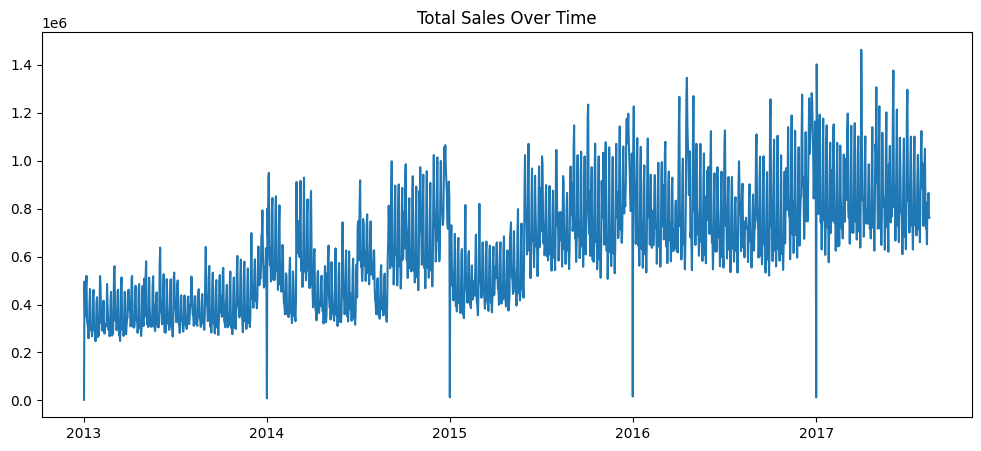

In [12]:
daily_sales=train.groupby('date')['sales'].sum()

plt.figure(figsize=(12,5))
plt.plot(daily_sales)
plt.title('Total Sales Over Time')
plt.show()

In [13]:
le = LabelEncoder()

train["family"] = le.fit_transform(train["family"])
test["family"] = le.transform(test["family"])

In [14]:
for df in [train, test]:
    
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.dayofweek

In [15]:
train["sales_original"] = train["sales"]

In [16]:
train = train.sort_values(["store_nbr","family","date"])

for lag in [1,7,14,28]:
    
    train[f"lag_{lag}"] = (
        train.groupby(["store_nbr","family"])["sales_original"]
        .shift(lag)
    )

train["rolling_mean_7"] = (
    train.groupby(["store_nbr","family"])["sales_original"]
    .shift(1)
    .rolling(7)
    .mean()
)

train["rolling_std_7"] = (
    train.groupby(["store_nbr","family"])["sales_original"]
    .shift(1)
    .rolling(7)
    .std()
)

In [17]:
train["sales"] = np.log1p(train["sales"])

In [18]:
train = train.dropna()

In [19]:
features = [
    "store_nbr",
    "family",
    "onpromotion",
    "year",
    "month",
    "day",
    "dayofweek",
    "oil_price",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_std_7"
]

In [20]:
X = train[features]
y = train["sales"]

X_train, X_val, y_train, y_val = train_test_split(
    X,y,test_size=0.2,random_state=42
)

# 🤖 Model Training

We train a **LightGBM Regressor**, which is well suited for large tabular datasets and handles non-linear relationships effectively.

Key advantages of LightGBM:

- Fast training
- Handles large datasets efficiently
- Good performance on tabular data

In [21]:
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    random_state=42
)

model.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053416 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2137
[LightGBM] [Info] Number of data points in the train set: 2360793, number of used features: 14
[LightGBM] [Info] Start training from score 2.941714


LGBMRegressor(learning_rate=0.05, n_estimators=500, num_leaves=64,
              random_state=42)

# 📏 Model Evaluation

The model is evaluated using **Root Mean Squared Logarithmic Error (RMSLE)**.

RMSLE is used because:

- Sales data is highly skewed
- It penalizes underestimation more than overestimation
- It aligns with the Kaggle competition metric

In [22]:
preds = model.predict(X_val)

rmsle = np.sqrt(mean_squared_log_error(
    np.expm1(y_val),
    np.expm1(preds)
))

print("Validation RMSLE:",rmsle)

Validation RMSLE: 0.37160884728922555


In [23]:
# create original sales column again
train["sales_original"] = np.expm1(train["sales"])

test["sales_original"] = np.nan

combined = pd.concat([train, test], sort=False)

combined = combined.sort_values(["store_nbr","family","date"])

for lag in [1,7,14,28]:

    combined[f"lag_{lag}"] = (
        combined.groupby(["store_nbr","family"])["sales_original"]
        .shift(lag)
    )

combined["rolling_mean_7"] = (
    combined.groupby(["store_nbr","family"])["sales_original"]
    .shift(1)
    .rolling(7)
    .mean()
)

combined["rolling_std_7"] = (
    combined.groupby(["store_nbr","family"])["sales_original"]
    .shift(1)
    .rolling(7)
    .std()
)

# 🔮 Generating Predictions

After training the model, predictions are generated for the test dataset.

Steps:

1. Apply the same feature engineering pipeline used during training
2. Generate predictions using the trained model
3. Convert predictions back to original scale using expm1()

In [24]:
combined["sales_original"] = np.expm1(combined["sales"])

In [25]:
predictions = []

test_dates = sorted(test["date"].unique())

for current_date in test_dates:

    # recompute lag features using updated history
    for lag in [1,7,14,28]:
        combined[f"lag_{lag}"] = (
            combined.groupby(["store_nbr","family"])["sales_original"]
            .shift(lag)
        )

    combined["rolling_mean_7"] = (
        combined.groupby(["store_nbr","family"])["sales_original"]
        .shift(1)
        .rolling(7)
        .mean()
    )

    combined["rolling_std_7"] = (
        combined.groupby(["store_nbr","family"])["sales_original"]
        .shift(1)
        .rolling(7)
        .std()
    )

    current_rows = combined[combined["date"] == current_date].copy()

    X_test = current_rows[features].fillna(0)

    preds_log = model.predict(X_test)

    preds = np.expm1(preds_log)

    preds = np.clip(preds,0,None)

    predictions.extend(preds)

    # update both columns
    combined.loc[current_rows.index,"sales"] = np.log1p(preds)
    combined.loc[current_rows.index,"sales_original"] = preds

In [26]:
submission = pd.DataFrame({
    "id": test["id"],
    "sales": predictions
})

submission.to_csv("submission.csv",index=False)

submission.head()

,id,sales
0,3000888,4.219564
1,3000889,0.033831
2,3000890,5.097474
3,3000891,2172.277718
4,3000892,0.031943


In [27]:
print(len(predictions))
print(len(test))

28512
28512


In [28]:
print(submission.head())
print(submission.describe())

        id        sales
0  3000888     4.219564
1  3000889     0.033831
2  3000890     5.097474
3  3000891  2172.277718
4  3000892     0.031943
                 id         sales
count  2.851200e+04  28512.000000
mean   3.015144e+06    430.143493
std    8.230850e+03   1143.726880
min    3.000888e+06      0.000000
25%    3.008016e+06      4.188513
50%    3.015144e+06     29.718755
75%    3.022271e+06    255.772170
max    3.029399e+06  13208.150877


In [29]:
print(pd.Series(predictions).describe())

count    28512.000000
mean       430.143493
std       1143.726880
min          0.000000
25%          4.188513
50%         29.718755
75%        255.772170
max      13208.150877
dtype: float64


# 📌 Conclusion

In this notebook we:

- Built a time series forecasting model
- Engineered lag and rolling statistical features
- Trained a LightGBM model
- Achieved a validation RMSLE close to **0.38**

Future improvements could include:

- Incorporating holiday and store metadata
- Using more advanced time-series models
- Hyperparameter optimization

# 🔗 Author

**Author:** Tushar Dobal  
**Competition:** Store Sales Time Series Forecasting  
**Model:** LightGBM  

If you found this notebook helpful, please consider **upvoting 👍**.